# Train separation U-Net on mel dataset

This notebook trains the conservative mel-spectrogram U-Net with a simple L1 loss.

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from dataset.mel_dataset import MelDataset, MelDatasetConfig, collate_mel_dataset
from model.separation_unet import SeparationUNet, SeparationUNetConfig


/home/matej/Documents/music_segmentation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MEL_ROOT = Path('../musdb18/mels')
TARGET_STEMS = ('drums', 'bass', 'other', 'vocals')
BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 20
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

train_ds = MelDataset(MelDatasetConfig(root_dir=MEL_ROOT, split='train', target_stems=TARGET_STEMS))
test_ds = MelDataset(MelDatasetConfig(root_dir=MEL_ROOT, split='test', target_stems=TARGET_STEMS))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_mel_dataset)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_mel_dataset)

model = SeparationUNet(SeparationUNetConfig(out_stems=len(TARGET_STEMS), stem_names=TARGET_STEMS)).to(DEVICE)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print('train size:', len(train_ds))
print('test size:', len(test_ds))
print('device:', DEVICE)

train size: 2266
test size: 1235
device: cuda


In [3]:
def run_epoch(loader, model, criterion, optimizer=None, device='cpu'):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in tqdm(loader, leave=False):
            mixture = batch.mixture.to(device)
            target = batch.target.to(device)

            pred = model(mixture)
            loss = criterion(pred, target)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * mixture.size(0)

    return total_loss / len(loader.dataset)


In [4]:
history = {'train_loss': [], 'test_loss': []}
best_test_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer=optimizer, device=DEVICE)
    test_loss = run_epoch(test_loader, model, criterion, optimizer=None, device=DEVICE)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)

    print(f'Epoch {epoch:03d} | train L1: {train_loss:.6f} | test L1: {test_loss:.6f}')

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'test_loss': test_loss,
        'target_stems': TARGET_STEMS,
    }
    torch.save(checkpoint, CHECKPOINT_DIR / 'last.pt')

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(checkpoint, CHECKPOINT_DIR / 'best.pt')


Epoch 001 | train L1: 0.161878 | test L1: 0.160212


Epoch 002 | train L1: 0.144356 | test L1: 0.161391


Epoch 003 | train L1: 0.141491 | test L1: 0.160851


Epoch 004 | train L1: 0.138447 | test L1: 0.148968


Epoch 005 | train L1: 0.135479 | test L1: 0.175306


...

Epoch 016 | train L1: 0.118168 | test L1: 0.137259


Epoch 017 | train L1: 0.117023 | test L1: 0.147671


Epoch 018 | train L1: 0.116657 | test L1: 0.146854


Epoch 019 | train L1: 0.115281 | test L1: 0.143929


Epoch 020 | train L1: 0.115009 | test L1: 0.139364


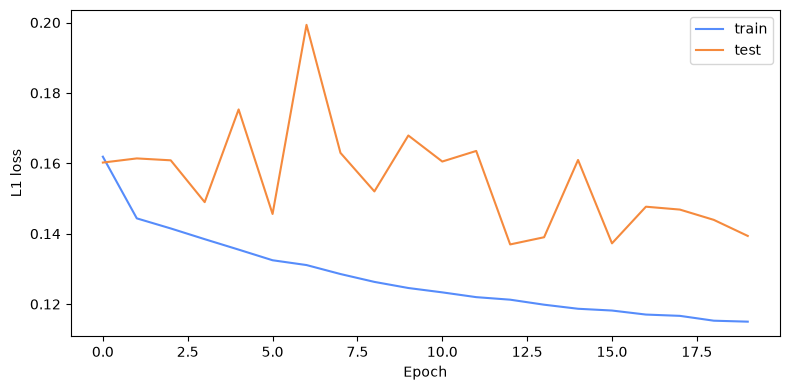

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['test_loss'], label='test')
plt.xlabel('Epoch')
plt.ylabel('L1 loss')
plt.legend()
plt.tight_layout()
plt.show()
